In [1]:
import matplotlib.pyplot as plt
import numpy as np
from nskernel import NonStationaryKernel
from scipy.optimize import fmin_l_bfgs_b
from spleaf import cov, term
import scipy.io as sp
import emcee


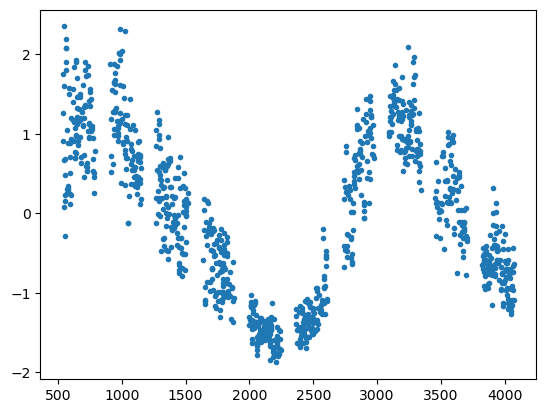

In [16]:
realis = 2
use_file = f"serie_res_bt_G2_1000_4m_NOISE0.09_OGS_MAG_M1_real{realis}.sav"
data = sp.readsav(use_file)

arr_len = len(data['tt'])
tt = data['tt']
rv = data['rv']
rhk = data['ca']
erv = np.zeros(len(rhk))+0.09
rhk_err = np.zeros(len(rhk))+5e-4

rv_mean = np.mean(rv)
rv_std  = np.std(rv)
rv_norm = (rv - rv_mean) / rv_std

# RHK normalization
rhk_mean = np.mean(rhk)
rhk_std  = np.std(rhk)
rhk_norm = (rhk - rhk_mean) / rhk_std

# ERROR normalization using SAME scaling as parent data
erv_norm     = erv / rv_std
rhk_err_norm = rhk_err / rhk_std

# erv_norm *=50
# rhk_err_norm *=50

T = [tt,tt]
Y = [rv_norm,rhk_norm]
Yerr = [erv_norm,rhk_err_norm]

t_full, y_full, yerr_full, series_index = cov.merge_series(T,Y,Yerr)

plt.plot(tt, rv_norm, ".")

In [17]:
# def alpha(t, a1, a2, b1, b2, pcyc):
#   fc = a1 * np.sin(2.0 * np.pi * t / pcyc) + a2 * np.cos(2.0 * np.pi * t / pcyc) + b1 * np.sin(4.0 * np.pi * t / pcyc) + b2 * np.cos(4.0 * np.pi * t / pcyc) 
#   R1 = np.sqrt(a1**2 + a2**2)
#   R2 = np.sqrt(b1**2 + b2**2)
#   Amax = R1 + R2

#   return (fc - (-Amax)) / (2 * Amax + 1e-14)

# def alpha(t, a1, a2, c, pcyc):
#   fc = a1 * np.sin(2.0 * np.pi * t / pcyc) + a2 * np.cos(2.0 * np.pi * t / pcyc) + c
#   R1 = np.sqrt(a1**2 + a2**2)
#   Amax = R1 

#   return (fc - (-Amax)) / (2 * Amax + 1e-14)


def alpha(t, pcyc, phi, k_raw, c):
    # constraint |k| <= 1/3
    k = (1.0 / 3.0) * np.tanh(k_raw)
    x = (2.0 * np.pi / pcyc) * t + phi

    fc = np.sin(x + k * np.sin(x))  # in [-1, 1]

    # linear normalization to [C, 1]
    return ((1.0 - c) / 2.0) * (fc + 1.0) + c


# def alpha_grad(t, a1, a2, c, pcyc):
#     k = 2.0 * np.pi / pcyc
#     s1 = np.sin(k * t)
#     c1 = np.cos(k * t)

#     fc = a1*s1 + a2*c1 + c

#     R1 = np.sqrt(a1*a1 + a2*a2)
#     Amax = R1 
#     eps = 1e-8
#     D = 2.0 * Amax + eps   # denominator

#     dfc = {
#         'a1': s1,
#         'a2': c1,
#         'c' : 1.0,
#     }

#     dR1 = {'a1': (a1 / (R1 + 1e-12)), 'a2': (a2 / (R1 + 1e-12)),'c':0}
#     dA = {
#         'a1': dR1['a1'],
#         'a2': dR1['a2'],
#         'c' : dR1['c']

#     }

#     numer = fc + Amax

#     grads = {}
#     for pname in ('a1','a2','c'):
#         df = dfc[pname]                # ∂fc/∂p
#         dA_dp = dA[pname]              # ∂Amax/∂p (scalar)
  
#         dD_dp = 2.0 * dA_dp

#         # d(alpha) = ( (df + dA_dp) * D - numer * dD_dp ) / D^2
#         grads[pname] = ((df + dA_dp) * D - numer * dD_dp) / (D*D)

#     dk_dp = -2.0 * np.pi / (pcyc**2)
#     df_dpcyc = a1 * (t * np.cos(k*t)) * dk_dp + \
#                a2 * (-t * np.sin(k*t)) * dk_dp
#     # similarly dA/dpcyc = 0 because Amax doesn't depend on pcyc
#     grads['pcyc'] = (df_dpcyc * D - numer * 0.0) / (D*D)

#     return grads

import numpy as np

def alpha_grad(t, pcyc, phi, k_raw, c):
    
    omega = 2.0 * np.pi / pcyc
    x = omega * t + phi

    k = (1.0 / 3.0) * np.tanh(k_raw)

    inner = x + k * np.sin(x)
    s_inner = np.sin(inner)
    c_inner = np.cos(inner)

    scale = (1.0 - c) / 2.0

    # d(inner)/dx
    d_inner_dx = 1.0 + k * np.cos(x)

    # d alpha / d s
    d_alpha_ds = scale

    # chain: d alpha / d inner
    d_alpha_dinner = d_alpha_ds * c_inner

    grads = {}

    # ----- derivative wrt phi -----
    # dx/dphi = 1
    grads['phi'] = d_alpha_dinner * d_inner_dx

    # ----- derivative wrt pcyc -----
    # omega = 2π/pcyc
    domega_dp = -2.0 * np.pi / (pcyc ** 2)
    dx_dp = domega_dp * t
    grads['pcyc'] = d_alpha_dinner * d_inner_dx * dx_dp

    # ----- derivative wrt k_raw -----
    # k = (1/3)tanh(k_raw)
    dk_dkraw = (1.0 / 3.0) * (1.0 - np.tanh(k_raw) ** 2)
    d_inner_dk = np.sin(x)
    grads['k_raw'] = d_alpha_dinner * d_inner_dk * dk_dkraw

    # ----- derivative wrt C -----
    # alpha = scale*(s+1) + C
    # scale = (1-C)/2
    # d alpha / dC = -(1/2)*(s+1) + 1
    grads['c'] = -0.5 * (s_inner + 1.0) + 1.0

    return grads



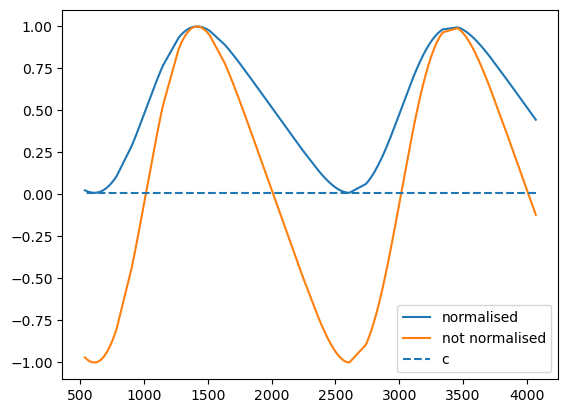

In [18]:
plt.plot(t_full, alpha(t_full, 2000, 3.1, 2,0.01),label="normalised")
plt.plot(t_full, np.sin((2.0 * np.pi / 2000) * t_full + 3.1 + (1.0 / 3.0) * np.tanh(2) * np.sin((2.0 * np.pi / 2000) * t_full + 3.1)),label="not normalised")
plt.hlines(0.01,np.max(t_full),np.min(t_full),linestyle="dashed",label="c")
plt.legend()

In [19]:
class MultiSeriesKernel(term.MultiSeriesKernel):
  def _grad_param(self, grad_dU=None, grad_dV=None):
    if grad_dU is not None or grad_dV is not None:
      raise NotImplementedError()
    return super()._grad_param()

In [46]:
stds = [np.std(y) for y in Y]
sig = np.var(y_full)   
prot = 20.0
Q = 1.0

rvjit = 0.1*stds[0]
rhkjit = 0.1*stds[1]

# a1, a2, c, pcyc = 0.5, -6.1, 2.0, 2500.0

pcyc, phi, k_raw, c = 2500.0, np.pi/10, 2.3, 0.01

# C = cov.Cov(
#   t_full,
#   err=term.Error(yerr_full),
#   rv_jit=term.InstrumentJitter(series_index[0], rvjit),
#   rhk_jit=term.InstrumentJitter(series_index[1], rhkjit),
#   gp= term.SimpleProductKernel(
#     nonstat=MultiSeriesKernelPatched(NonStationaryKernel(alpha, alpha_grad, a1=a1, a2=a2, b1=b1, b2=b2, c=c, pcyc=pcyc),series_index, 
#         np.ones(2) * stds, 
#         np.array([stds[0], 0.0])), 
#     rot = 
#         MultiSeriesKernelPatched(term.SHOKernel( # this term represents the rotation
#                 sig, # st.dev. sig (should be 1)
#                 prot, # period P, in days
#                 Q, # quality factor Q
#         ), series_index, 
#         np.ones(2) * stds, 
#         np.array([stds[0], 0.0])
#     ),
#   )
# )



C = cov.Cov(
  t_full,
  err=term.Error(yerr_full),
  rv_jit=term.InstrumentJitter(series_index[0], rvjit),
  rhk_jit=term.InstrumentJitter(series_index[1], rhkjit),
  gp=term.SimpleProductKernel(
      nonstat=NonStationaryKernel(alpha, alpha_grad, pcyc=pcyc, phi = phi, k_raw = k_raw, c = c),
      rot = MultiSeriesKernel(term.SHOKernel(sig,prot, Q), series_index, 
        np.ones(2) * stds, 
        np.array([stds[0], 0.0])
    ),
  )
)
          
  # gp=term.MultiSeriesKernel(term.SimpleProductKernel(
  #   nonstat=NonStationaryKernel(alpha, alpha_grad, pcyc=pcyc, phi = phi, k_raw = k_raw, c = c), 
  #   rot = term.SHOKernel( # this term represents the rotation
  #               sig, # st.dev. sig (should be 1)
  #               prot, # period P, in days
  #               Q, # quality factor Q
  #       )), series_index, 
  #       np.ones(2) * stds, 
  #       np.array([stds[0], 0.0])
  #   ),
  # )



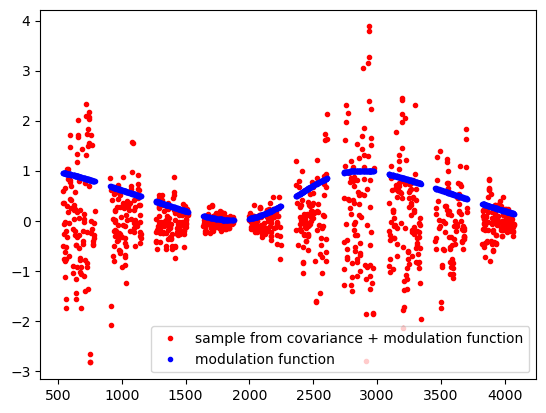

In [47]:
fc_norm = alpha(t_full[series_index[0]], pcyc, phi, k_raw, c)
drawn_sample = C.sample()[series_index[0]]

plt.plot(t_full[series_index[0]], drawn_sample, ".", color="red", label="sample from covariance + modulation function")
plt.plot(t_full[series_index[0]], fc_norm, ".", color="blue", label="modulation function")
plt.legend()

In [78]:
rvjit_max = 5*stds[0]
rhkjit_max = 5*stds[1]

prot_min = 17.0
prot_max = 25.0
Q_min = 0.01
Q_max = 10.0

pcyc_min = 2000.0
pcyc_max = 3000.0

alpha_0_max = 5*stds[0]
alpha_1_max = 5*stds[1]
beta_0_max  = 5*stds[0]
beta_1_max  = 5*stds[1]
gamma_0_max = 5*stds[0]
gamma_1_max = 5*stds[1]

bounds_list = [
    (0.001, rvjit_max),                     # rv_jit.sig
    (0.001, rhkjit_max),                     # rhk_jit.sig
    (pcyc_min, pcyc_max),  
    (-np.pi,np.pi),
    (-20,20),
    (-0.01,0.99),
    # (-10,10),
    
    (prot_min, prot_max),                 # rot.P0 (period)
    (Q_min, Q_max),                      # rot.Q (quality factor)
    (0, alpha_0_max),         # rot.alpha_0 (set lower bound to zero)
    (-alpha_1_max, alpha_1_max),         # rot.alpha_1
    (-beta_0_max, beta_0_max),         # rot.beta_0      # rot.beta_1
    (-gamma_0_max, gamma_0_max),         # rot.gamma_0
    (-gamma_1_max, gamma_1_max),         # rot.gamma_1
    (-gamma_0_max, gamma_0_max),         # delta_0 (offset for series 0)
    (-gamma_1_max, gamma_1_max),         # delta_1 (offset for series 1)
]

C.param

['rv_jit.sig',
 'rhk_jit.sig',
 'gp.nonstat_pcyc',
 'gp.nonstat_phi',
 'gp.nonstat_k_raw',
 'gp.nonstat_c',
 'gp.rot_sig',
 'gp.rot_P0',
 'gp.rot_Q',
 'gp.rot_alpha_0',
 'gp.rot_alpha_1',
 'gp.rot_beta_0',
 'gp.rot_beta_1']

In [79]:
fitted = [k for k, key in enumerate(C.param) if key != 'gp.rot_sig' and key != "gp.rot_beta_1"]  
params = [C.param[k] for k in fitted]
x0 = C.get_param(params)

x0 = np.append(x0,[0.0,0.0,0.0,0.0])

print(len(x0), len(bounds_list))

def negloglike(x, y, C):
  
  C.set_param(x[:len(params)], params)
  fc = alpha(t_full, x[2],x[3],x[4],x[5])
  y_model = y.copy()
  y_model[series_index[0]] -= (x[-4]*fc[series_index[0]] + x[-2])
  y_model[series_index[1]] -= (x[-3]*fc[series_index[1]] + x[-1])
  nll = -C.loglike(y_model)
  # gradient
  lg = C.loglike_grad()
  dL_dy = np.asarray(lg[0]).reshape(-1)      # shape (N_total,) 
  dL_dparams = np.asarray(lg[1]).reshape(-1) # shape (12,)      

  base_grad = - dL_dparams[fitted]  

  # gradients wrt gamma (scale of fc)
  grad_gamma_0 = np.sum(dL_dy[series_index[0]] * fc[series_index[0]])
  grad_gamma_1 = np.sum(dL_dy[series_index[1]] * fc[series_index[1]])
  # gradients wrt delta (additive offsets)
  grad_delta_0 = np.sum(dL_dy[series_index[0]])
  grad_delta_1 = np.sum(dL_dy[series_index[1]])

  nll_grad = np.concatenate([np.asarray(base_grad).ravel(), np.array([grad_gamma_0, grad_gamma_1, grad_delta_0, grad_delta_1])])


  # nll_grad = -C.loglike_grad()[1][fitted]

  return (nll, nll_grad)


result = fmin_l_bfgs_b(negloglike, x0, args=(y_full, C), bounds=bounds_list)
xbest = result[0]

C.set_param(xbest[:len(params)], params)
C.set_param([0.0], ['gp.rot_beta_1'])


print(params)
print(xbest)

15 15
['rv_jit.sig', 'rhk_jit.sig', 'gp.nonstat_pcyc', 'gp.nonstat_phi', 'gp.nonstat_k_raw', 'gp.nonstat_c', 'gp.rot_P0', 'gp.rot_Q', 'gp.rot_alpha_0', 'gp.rot_alpha_1', 'gp.rot_beta_0']
[ 2.49774806e-01  1.27739116e-03  2.27654876e+03  3.14159265e+00
  4.21694056e+00  8.66038706e-01  2.50000000e+01  4.42290213e-02
  1.05219693e+00  1.13276596e+00 -3.25198639e-01 -7.87141434e-01
  7.67856669e-01  7.40066758e-01 -7.12721741e-01]


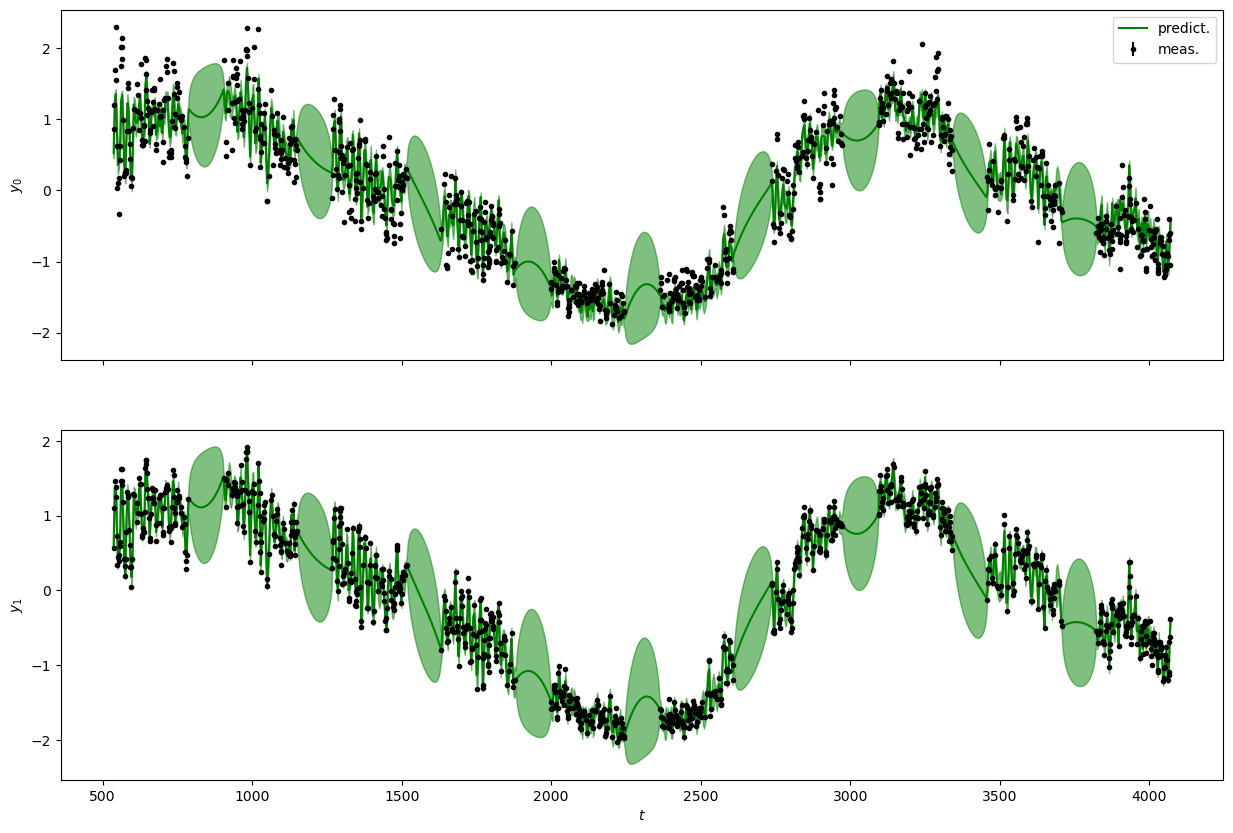

In [80]:
# C.set_param([0.0], ['gp.beta_0'])  
# C.set_param(xbest)

# C.set_param(samples[-1,0,:], params)

tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))


for k in range(2):
  # Predict time series k
  C.kernel['gp'].set_conditional_coef(series_id=k)
  # C.kernel['rot'].set_conditional_coef(series_id=k)
  fc = alpha(t_full, xbest[2],xbest[3],xbest[4],xbest[5])

  y_model = y_full.copy()
  y_model[series_index[0]] -= (xbest[-4]*fc[series_index[0]] + xbest[-2])
  y_model[series_index[1]] -= (xbest[-3]*fc[series_index[1]] + xbest[-1])

  mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_model, T[k], calc_cov='diag')
  if k == 0:
    res_rv = Y[k] - mu_res
  else:
    res_rhk = Y[k] - mu_res
  # Plot
  
  ax = axs[k]
  if k ==0 :
    ax.errorbar(T[k], Y[k]-(xbest[-4]*fc[series_index[0]]+xbest[-2]), Yerr[k], fmt='.', color='k', label='meas.')
  if k == 1:
    ax.errorbar(T[k], Y[k]-(xbest[-3]*fc[series_index[1]]+xbest[-1]), Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()

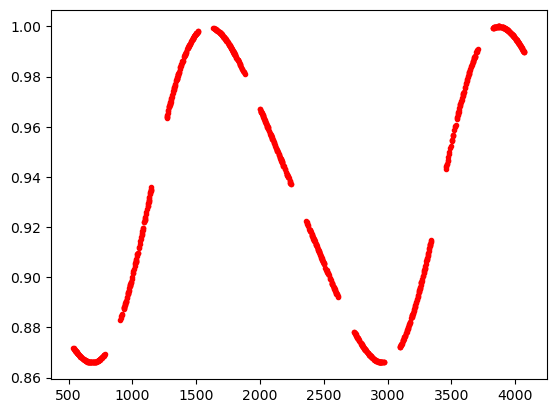

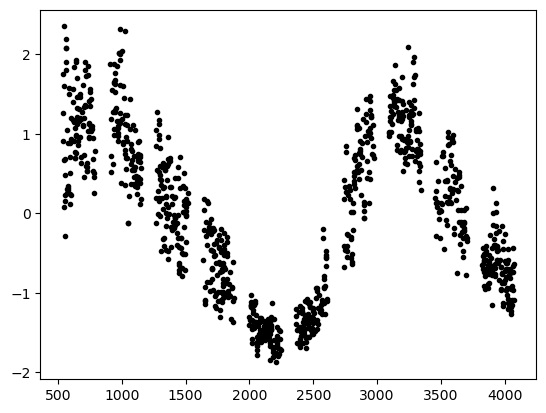

In [81]:
fc = alpha(t_full, xbest[2],xbest[3],xbest[4],xbest[5])
plt.figure()
plt.plot(t_full[series_index[0]],fc[series_index[0]], ".", color="red", label="fitted modulation function")
plt.figure()
plt.plot(t_full[series_index[0]],y_full[series_index[0]],".",color="black")

In [ ]:
def log_prior(theta):
    # unpack theta (added delta_0, delta_1 as final two entries)
    rv_jit, rhk_jit, pcyc, phi, k_raw, c, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, gamma_0, gamma_1, delta_0, delta_1 = theta
    if 0.0 < rv_jit < rvjit_max and 0.0 < rhk_jit < rhkjit_max and pcyc_min < pcyc < pcyc_max and -np.pi < phi < np.pi and -10< k_raw < 10 and 0.01 < c < 0.99 and prot_min < rot_P0 < prot_max and Q_min < rot_Q < Q_max and 0.0 < rot_alpha_0 < alpha_0_max and -alpha_1_max < rot_alpha_1 < alpha_1_max and -beta_0_max < rot_beta_0 < beta_0_max and -gamma_0_max < gamma_0 < gamma_0_max and -gamma_1_max < gamma_1 < gamma_1_max and -gamma_0_max < delta_0 < gamma_0_max and -gamma_1_max < delta_1 < gamma_1_max:
        return 0.0
    return -np.inf

def log_probability(theta, y, C):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + -1*negloglike(theta, y, C)[0]

x0 = xbest.copy()
print(x0)
print(log_prior(x0))    

# x0 = [0.03, 0.2, 1500.0, 0.015, 4.0, 4.0, 4.0]
ndim = len(x0)
pos = x0 + 1e-4 * np.random.randn(ndim*3, ndim)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(y_full, C)
)
sampler.run_mcmc(pos, 2000, progress=True);



[ 2.49774806e-01  1.27739116e-03  2.27654876e+03  3.14159265e+00
  4.21694056e+00  8.66038706e-01  2.50000000e+01  4.42290213e-02
  1.05219693e+00  1.13276596e+00 -3.25198639e-01 -7.87141434e-01
  7.67856669e-01  7.40066758e-01 -7.12721741e-01]
-inf


  0%|          | 0/2000 [00:00<?, ?it/s]/opt/anaconda3/envs/sleaf/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
  6%|▌         | 117/2000 [00:05<01:54, 16.49it/s]

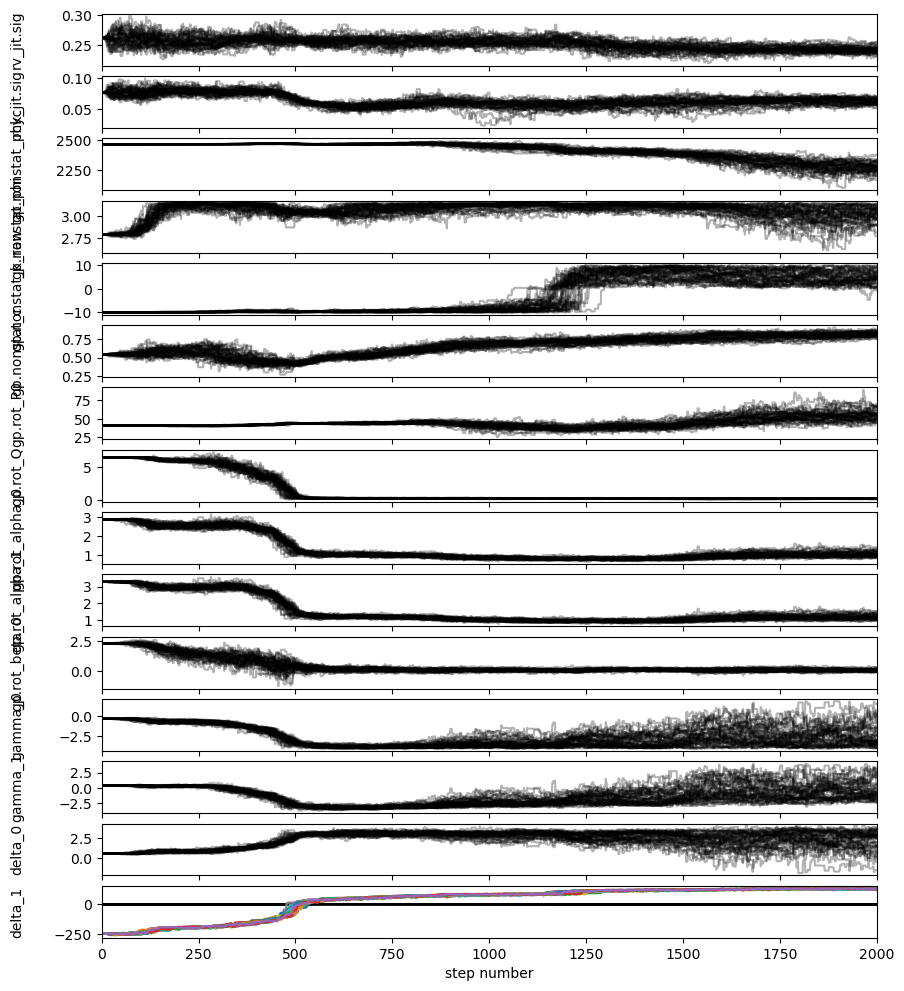

In [56]:
# ig, axes = plt.subplots(13, figsize=(10, 12), sharex=True)
ig, axes = plt.subplots(len(params) + 4, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()
labels = params + ['gamma_0', 'gamma_1', 'delta_0', 'delta_1']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

logp = sampler.get_log_prob(flat=False)
axes[-1].plot(logp)

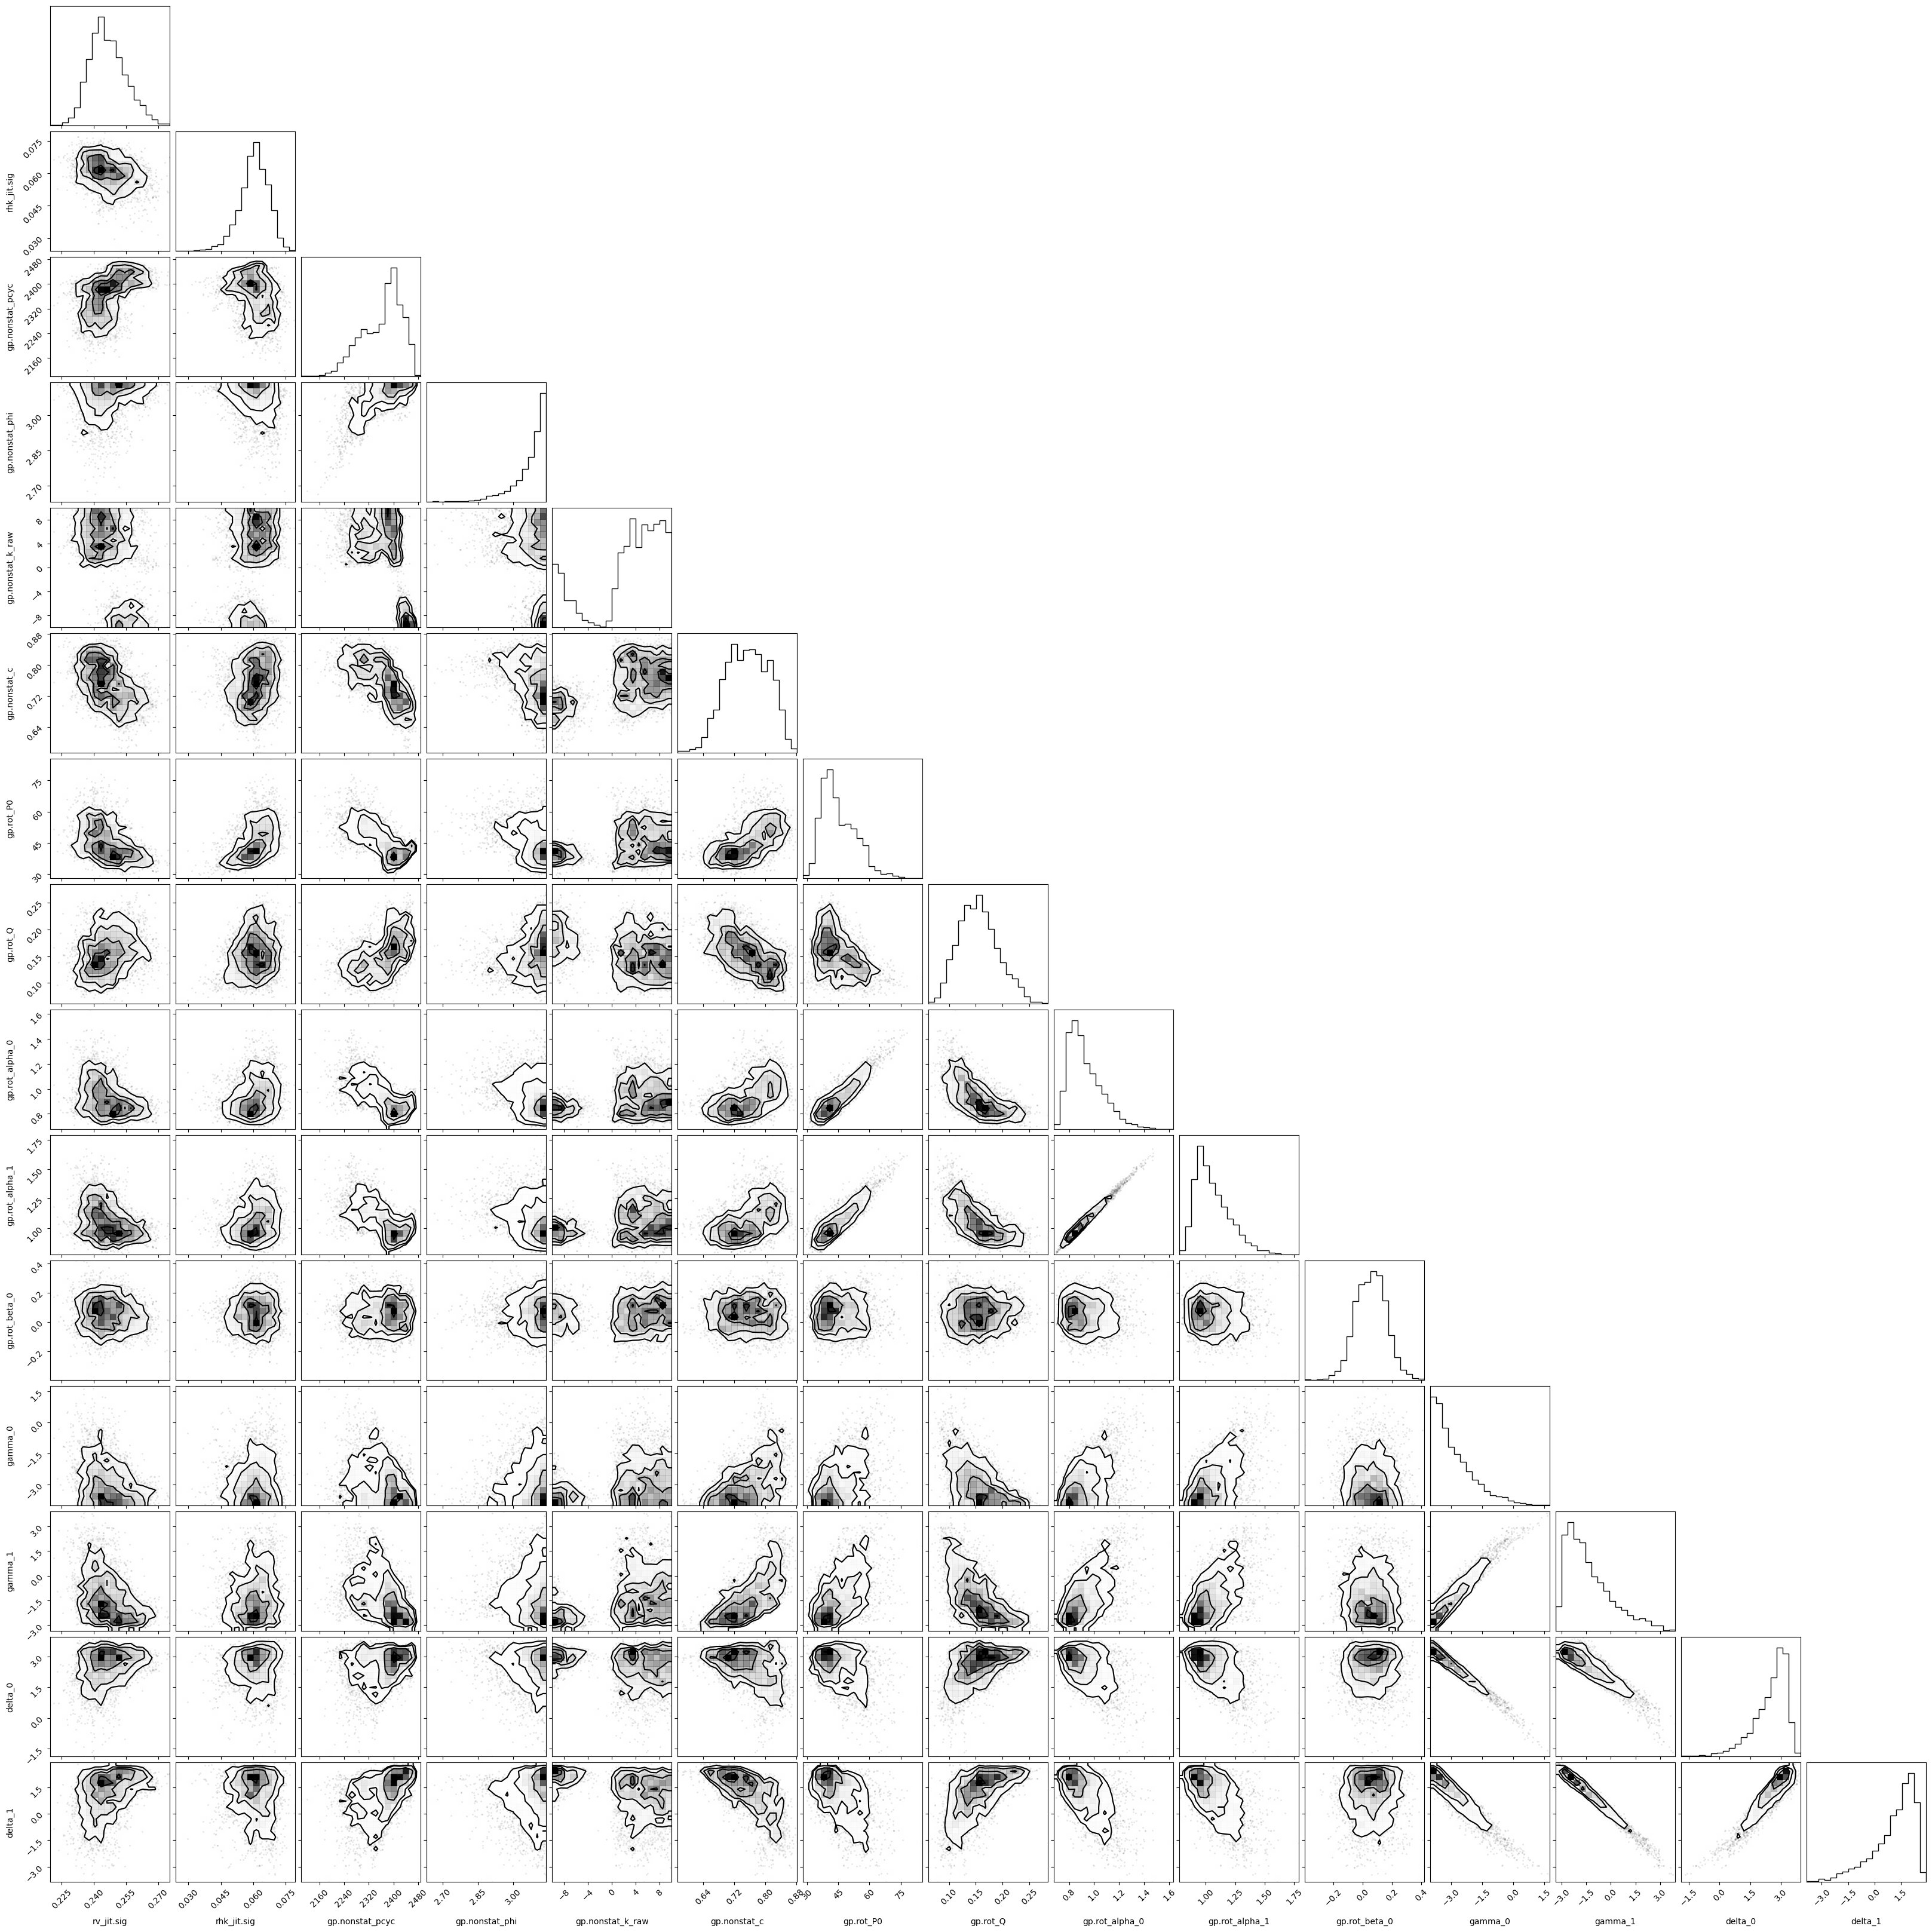

In [57]:
import corner

flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

fig = corner.corner(
    flat_samples, labels=labels
);



In [37]:
burn = 2000   
thin = 1

flat_samples = sampler.get_chain(discard=burn, thin=thin, flat=True)   # shape (n_samples, ndim)
flat_logp    = sampler.get_log_prob(discard=burn, thin=thin, flat=True) # shape (n_samples,)

finite_mask = np.isfinite(flat_logp)
flat_samples = flat_samples[finite_mask]
flat_logp    = flat_logp[finite_mask]

map_idx = np.argmax(flat_logp)
map_sample = flat_samples[map_idx]
map_logp = flat_logp[map_idx]

print("MAP index (in flattened, post-burn chain):", map_idx)
print("MAP log-posterior:", map_logp)
print("MAP sample (theta):", map_sample)

MAP index (in flattened, post-burn chain): 111079
MAP log-posterior: 128.88294688050155
MAP sample (theta): [ 2.42405793e-01  5.30365471e-02  2.25887791e+03  6.27234536e-01
  1.81202277e+00  9.45104702e-01  2.97601472e+01  1.25101723e-01
  7.47079922e-01  7.58694172e-01  5.64331510e-02  3.43801258e+00
 -3.82937185e+00 -3.41783702e+00  3.62040054e+00]


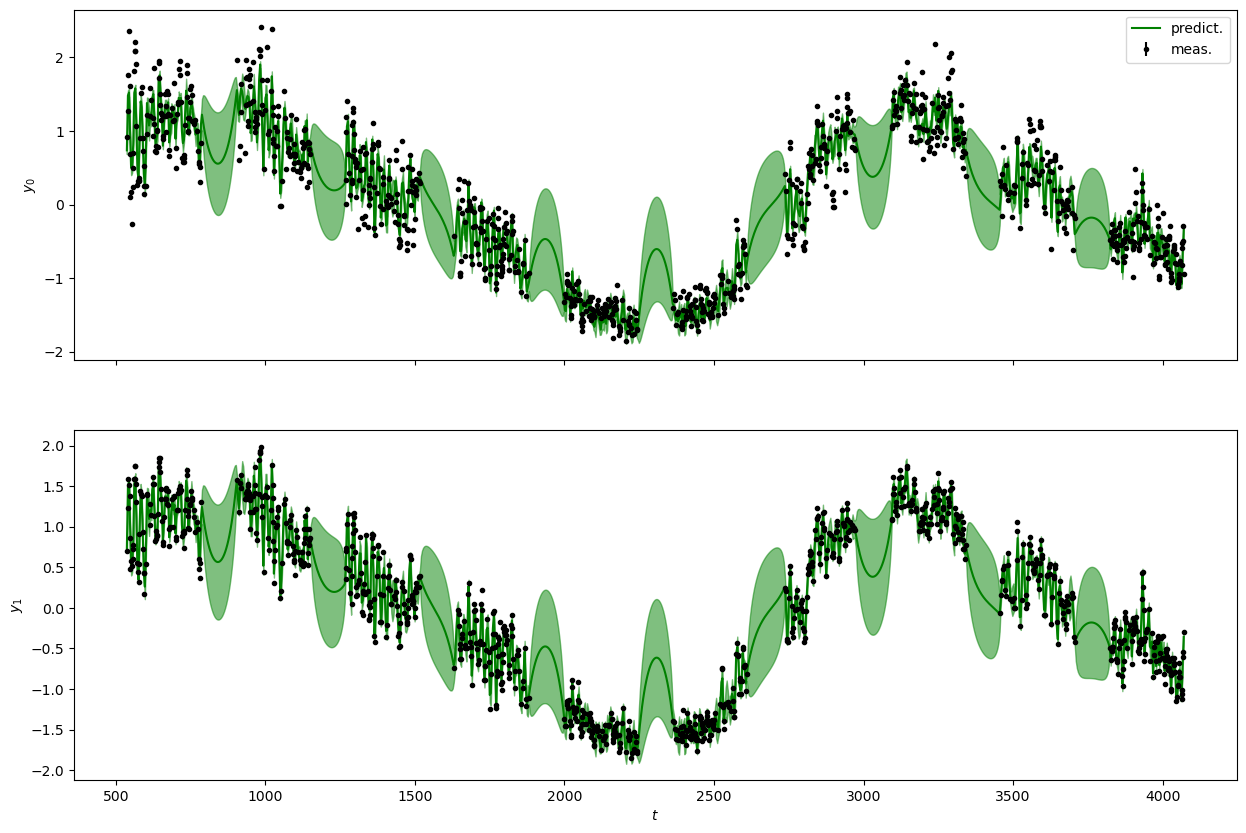

In [39]:
C.set_param(map_sample[:len(params)], params)
C.set_param([0.0], ['gp.rot_beta_1'])
C.set_param([np.var(y_full)], ['gp.rot_sig'])


tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))


for k in range(2):
  # Predict time series k
  C.kernel['gp'].set_conditional_coef(series_id=k)
  # C.kernel['rot'].set_conditional_coef(series_id=k)
  # use MAP sample for modulation and offsets
  fc = alpha(t_full, map_sample[2], map_sample[3], map_sample[4],map_sample[5])

  y_model = y_full.copy()
  # map_sample tail: [..., gamma_0, gamma_1, delta_0, delta_1]
  y_model[series_index[0]] -= map_sample[-4]*fc[series_index[0]] + map_sample[-2]
  y_model[series_index[1]] -= map_sample[-3]*fc[series_index[1]] + map_sample[-1]
  mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_model, T[k], calc_cov='diag')
  if k == 0:
    res_rv = Y[k] - mu_res
  else:
    res_rhk = Y[k] - mu_res
  # Plot
  
  ax = axs[k]
  if k ==0 :
    ax.errorbar(T[k], Y[k]-(map_sample[-4]*fc[series_index[0]]+map_sample[-2]), Yerr[k], fmt='.', color='k', label='meas.')
  if k == 1:
    ax.errorbar(T[k], Y[k]-(map_sample[-3]*fc[series_index[1]]+map_sample[-1]), Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()